# Дашборд конверсий. 

***

## Загрузка данных

Подключение необходимых модулей

In [5]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from dotenv import load_dotenv

Подключение данных из .env

In [7]:
load_dotenv()

DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')
API_URL = os.getenv('API_URL')

Выгрузка данных: 
- Начало: 2023-03-01
- Конец: 2023-09-01
- API: https://data-charts-api.hexlet.app
- ads: https://drive.google.com/uc?id=12vCtGhJlcK_CBcs8ES3BfEPbk6OJ45Qj

In [9]:
env_datasets = ['visits', 'registrations']
def load_from_env() -> dict: 
    result = {}
    for dataset in env_datasets: 
        data = requests.get(f'{API_URL}/{dataset}', params={'begin': DATE_BEGIN, 'end': DATE_END})
        data.raise_for_status()
        result[dataset] = pd.DataFrame(data.json())
    return result

datasets = load_from_env()
ads = pd.read_csv('https://drive.google.com/uc?id=12vCtGhJlcK_CBcs8ES3BfEPbk6OJ45Qj')
datasets['ads'] = ads

***

In [11]:
def cleaning_and_agg(data):
    result = {}
    for dataset_name, df in data.items(): 
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce') if 'datetime' in df.columns else pd.to_datetime(df['date'], errors='coerce')
        df['date_group'] = df['datetime'].dt.date
        df = df.sort_values(by='datetime')

        if dataset_name == 'visits': 
            df = df[df['platform'] != 'bot']
            df = df.drop_duplicates(subset='visit_id', keep='last')
            df_agg = df.groupby(['date_group', 'platform'])[['visit_id']].count().reset_index()
            df_agg = df_agg.rename(columns={'visit_id': 'visits'})
        
        elif dataset_name == 'registrations':
            df_agg = df.groupby(['date_group', 'platform'])[['user_id']].count().reset_index()
            df_agg = df_agg.rename(columns={'user_id': 'registrations'})
            df_agg = df_agg[df_agg['platform'] != 'bot']

        elif dataset_name == 'ads': 
            df_agg = df.groupby(['date_group', 'utm_source', 'utm_campaign'])[['cost']].sum().reset_index()
            df_agg = df_agg.rename(columns={'cost': 'ads_cost'})

        result[dataset_name] = df_agg
    return result

data = cleaning_and_agg(datasets)
visits = data['visits']
regs = data['registrations']
ads = data['ads']

***

## Визиты

In [14]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date_group  552 non-null    object
 1   platform    552 non-null    object
 2   visits      552 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 13.1+ KB


In [15]:
visits.describe()

,visits
count,552.000000
mean,251.273551
std,309.435871
min,7.000000
25%,36.000000
50%,74.500000
75%,473.250000
max,1295.000000


In [16]:
visits.head(10)

,date_group,platform,visits
0,2023-03-01,android,75
1,2023-03-01,ios,22
2,2023-03-01,web,279
3,2023-03-02,android,67
4,2023-03-02,ios,31
5,2023-03-02,web,515
6,2023-03-03,android,26
7,2023-03-03,ios,40
8,2023-03-03,web,617
9,2023-03-04,android,94


***

## Регистрации

In [19]:
regs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date_group     552 non-null    object
 1   platform       552 non-null    object
 2   registrations  552 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 13.1+ KB


In [20]:
regs.describe()

,registrations
count,552.000000
mean,39.557971
std,22.078237
min,6.000000
25%,23.000000
50%,34.000000
75%,54.000000
max,114.000000


In [21]:
regs.head(10)

,date_group,platform,registrations
0,2023-03-01,android,61
1,2023-03-01,ios,18
2,2023-03-01,web,8
3,2023-03-02,android,59
4,2023-03-02,ios,24
5,2023-03-02,web,23
6,2023-03-03,android,22
7,2023-03-03,ios,34
8,2023-03-03,web,51
9,2023-03-04,android,77


## Рекламы

In [23]:
ads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date_group    159 non-null    object
 1   utm_source    159 non-null    object
 2   utm_campaign  159 non-null    object
 3   ads_cost      159 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 5.1+ KB


In [24]:
ads.describe()

,ads_cost
count,159.000000
mean,194.836478
std,60.272154
min,100.000000
25%,143.000000
50%,190.000000
75%,252.000000
max,298.000000


In [25]:
ads.head(10)

,date_group,utm_source,utm_campaign,ads_cost
0,2023-03-01,google,advanced_algorithms_series,212
1,2023-03-02,google,advanced_algorithms_series,252
2,2023-03-03,google,advanced_algorithms_series,202
3,2023-03-04,google,advanced_algorithms_series,223
4,2023-03-05,google,advanced_algorithms_series,265
5,2023-03-06,google,advanced_algorithms_series,108
6,2023-03-07,google,advanced_algorithms_series,165
7,2023-03-08,google,advanced_algorithms_series,155
8,2023-03-09,google,advanced_algorithms_series,124
9,2023-03-10,google,advanced_algorithms_series,276


***

## Объединение данных и генерирование JSON-файлов

In [28]:
def data_merge(visits, regs): 
    data = pd.merge(
        visits, 
        regs, 
        how='outer', 
        on=['date_group', 'platform']
    )
    data = pd.merge(
        data, 
        ads, 
        how='left', 
        on=['date_group']
    )
    
    data = data[['date_group', 'platform', 'visits', 'registrations', 'utm_source', 'ads_cost']]
    data['conversion'] = data['registrations'] * 100.00 / data['visits']
    return data 

data = data_merge(visits, regs)
conversion = data[['date_group', 'platform', 'visits', 'registrations', 'conversion']]
conversion.to_json('./conversion.json')

In [29]:
ads_con = conversion.groupby(['date_group'])[['visits', 'registrations']].agg('sum').reset_index()
ads_json = pd.merge(
    ads_con, 
    ads, 
    how='left', 
    on='date_group'
)[['date_group', 'visits', 'registrations', 'ads_cost', 'utm_campaign']]
ads_json.columns = [['date_group', 'visits', 'registrations', 'cost', 'utm_campaign']]
ads_json.to_json('./ads.json')

In [30]:
os.makedirs("charts", exist_ok=True)

## Функция METRIC_BY_PLATFORM()

In [32]:
def metric_by_platform(index, column, values, save_name):
    for value in values: 
        pivot = data.pivot_table(
            index=index,
            columns=column,
            values=value,
            aggfunc='sum'
        )
        pivot.plot(kind='bar', stacked=True, figsize=(50, 15), grid=True)
        
        if value == 'visits': 
            plt.title('Визиты по платформам', fontsize=24)
            plt.ylabel('Количество визитов', fontsize=24)
        
        elif value == 'registrations': 
            plt.title('Регистрации по платформам', fontsize=24)
            plt.ylabel('Количество регистрации', fontsize=24)
            
        plt.legend(fontsize=20)
        plt.xlabel('Дата', fontsize=24)
        plt.savefig(f'./charts/{save_name}.png')     
        

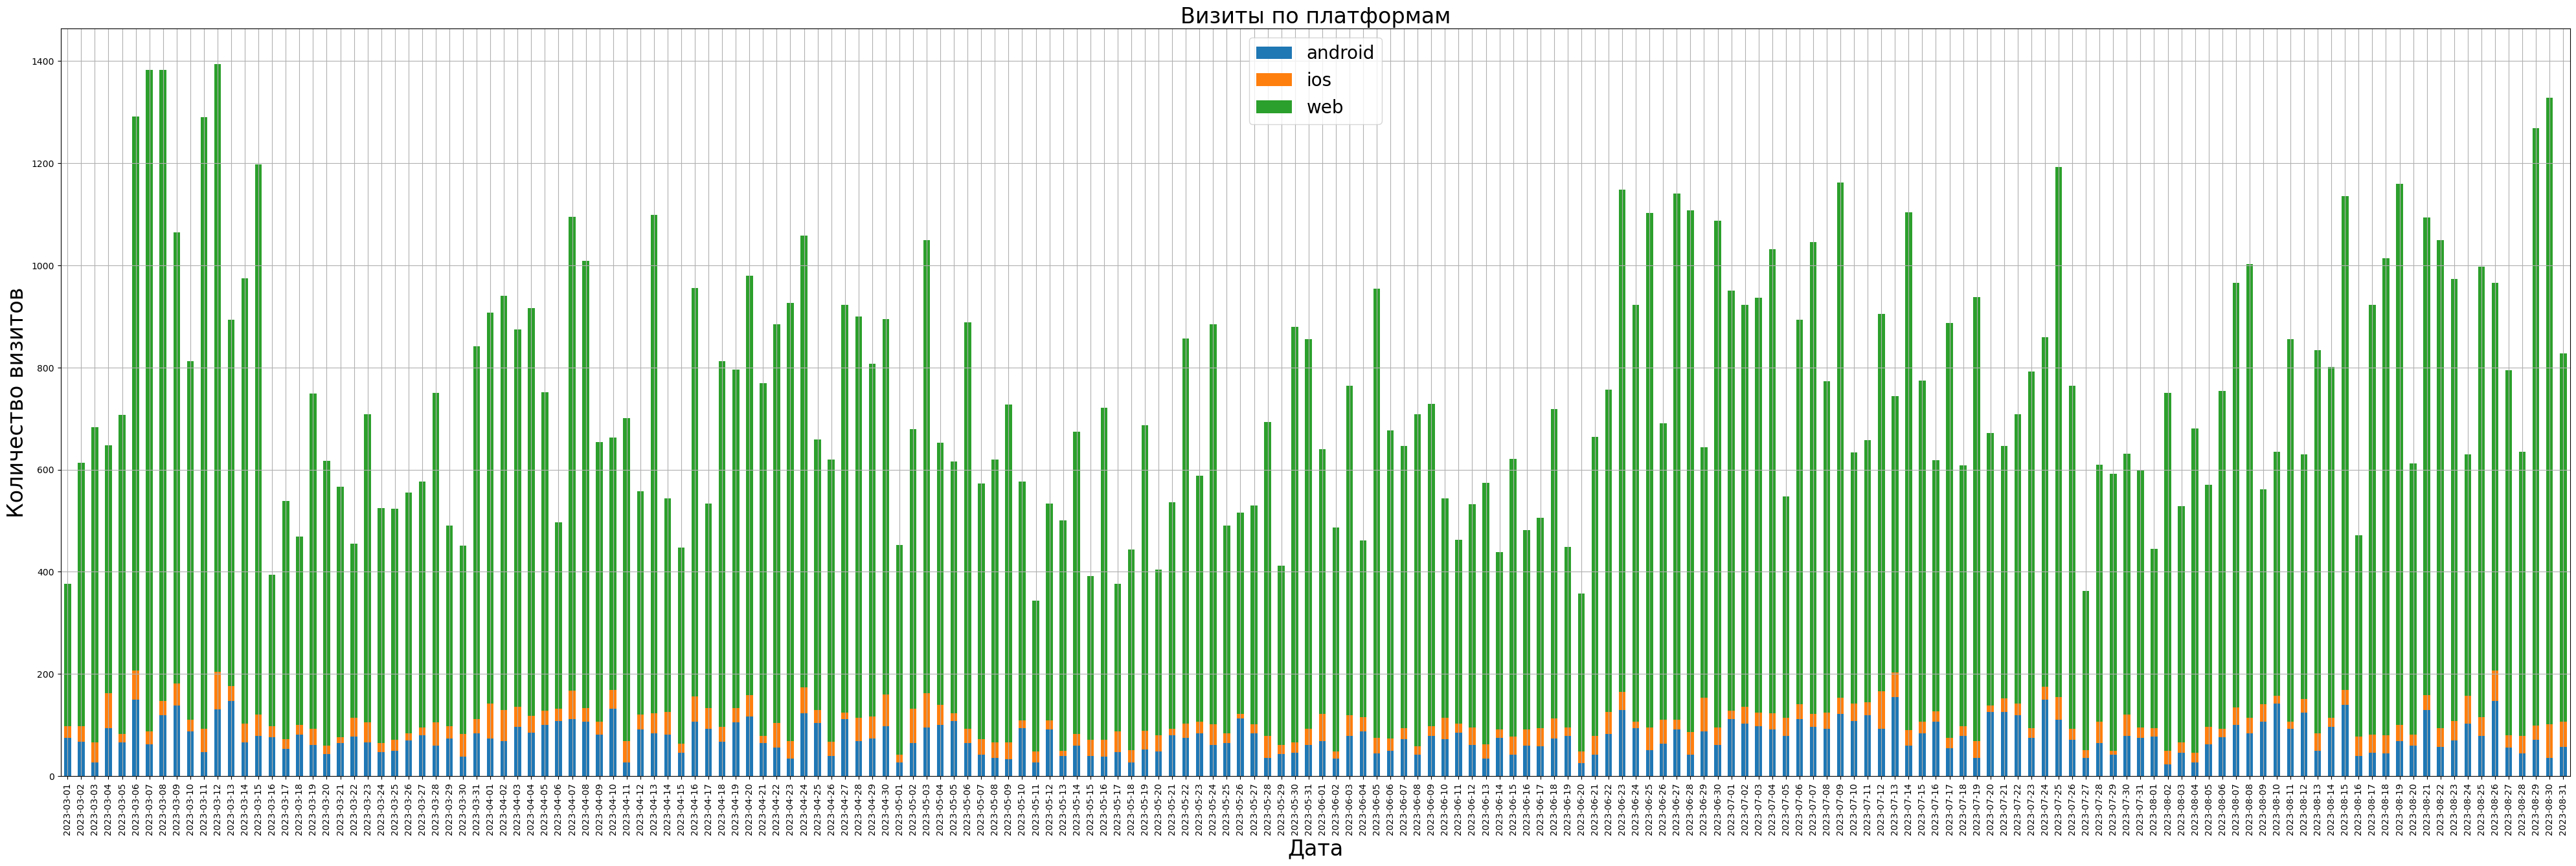

In [33]:
metric_by_platform(index='date_group', column='platform', values=['visits'], save_name='visits')

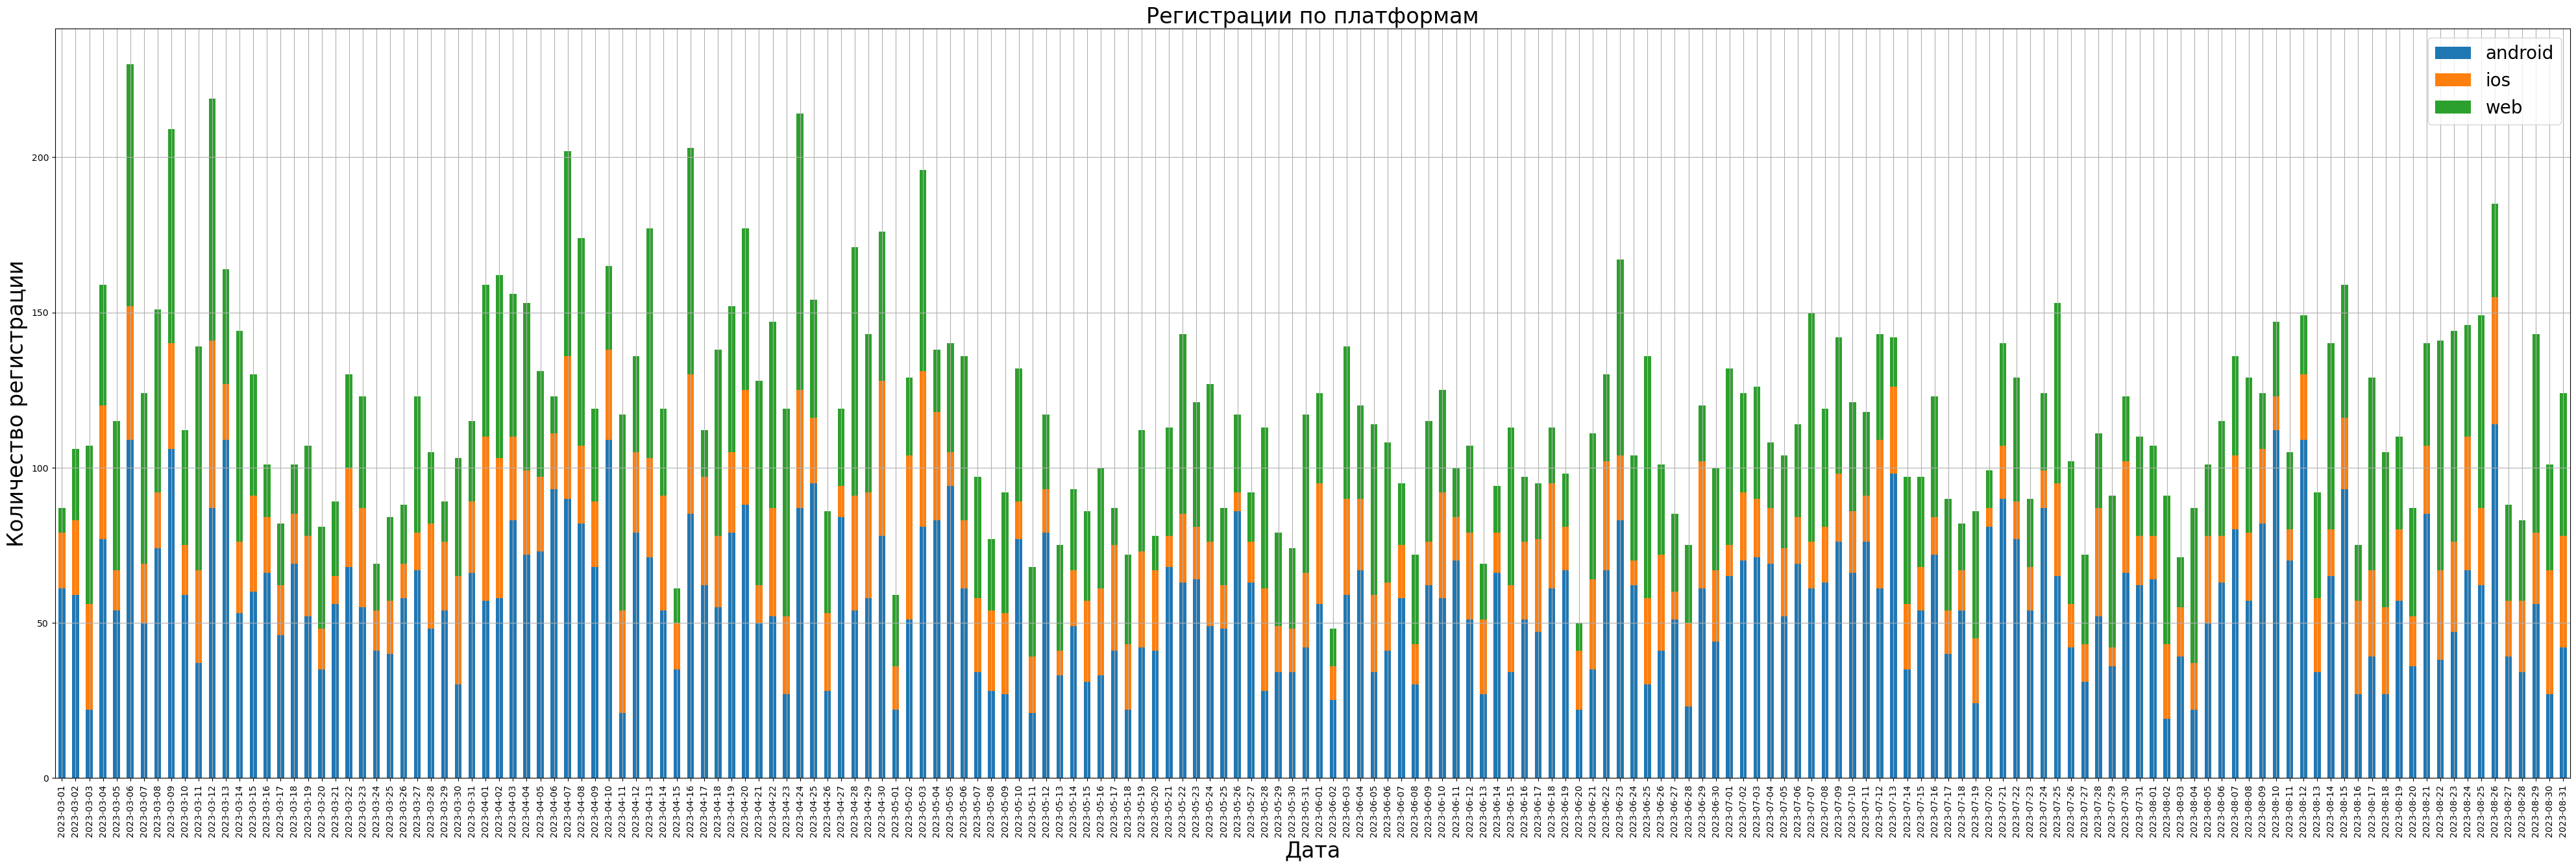

In [34]:
metric_by_platform(index='date_group', column='platform', values=['registrations'], save_name='registrations')

## Функция ALL_METRICS()

In [36]:
def all_metrics(): 
    df = data.copy() 
    df = df.groupby('date_group')[['visits', 'registrations']].agg('sum').reset_index()

    plt.figure(figsize=(40, 20))
    plt.plot(df['date_group'], df['visits'], marker='o', label='Визиты')
    plt.plot(df['date_group'], df['registrations'], marker='s', label='Регистрации')

    for i in ['visits', 'registrations']: 
        for x, y in zip(df['date_group'], df[i]): 
            plt.text(x, y, str(y), fontsize=12, ha='center', va='bottom')

    plt.xlim(left=df['date_group'].min(), right=df['date_group'].max())
    plt.title('Динамика визитов и регистраций по дням', fontsize=24)
    plt.xlabel('Дата', fontsize=20)
    plt.ylabel('Количество', fontsize=20)
    plt.xticks(rotation=45, fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(True)
    plt.legend(fontsize=18)
    plt.savefig('./charts/both_metrics.png')

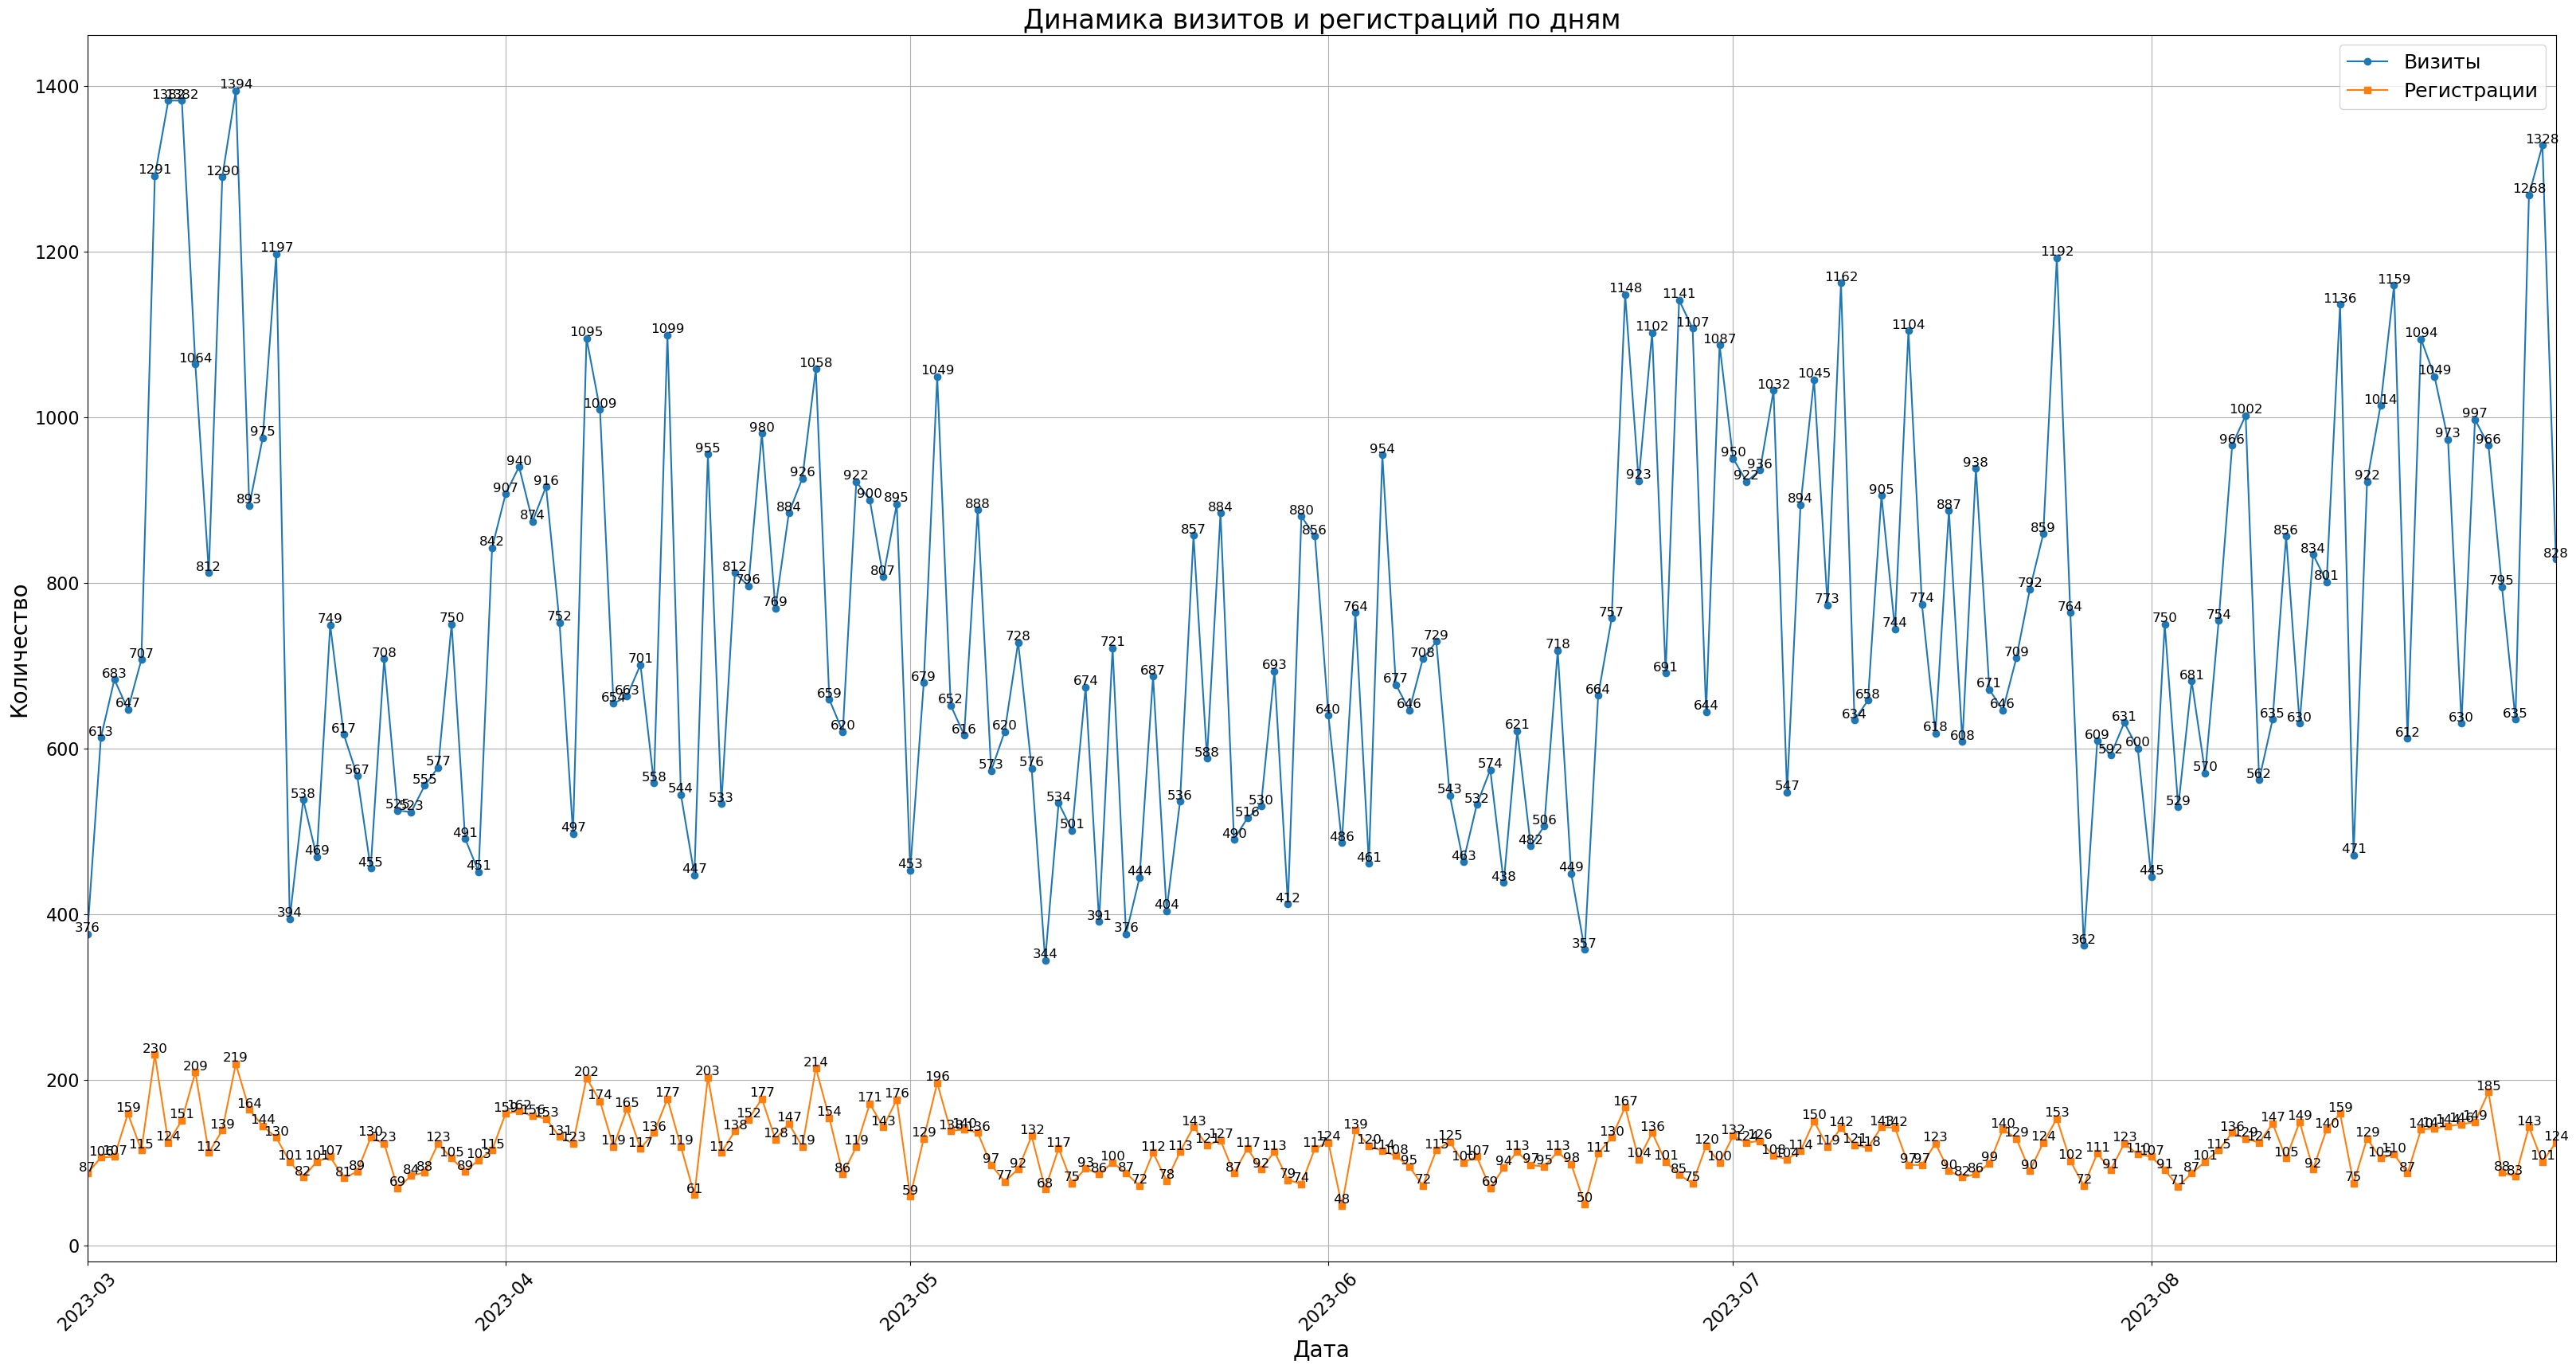

In [37]:
all_metrics()

## Функция PLATFORMS()

In [39]:
def platforms(dataframes, y_col, colors, titles, save_path):
    
    fig, ax = plt.subplots(3, 1, figsize=(50, 30))

    for i, df in enumerate(dataframes):
        df[['date_group', y_col]].plot(
            kind='line',
            x='date_group',
            y=y_col,
            marker='o',
            grid=True,
            ax=ax[i],
            color=colors[i]
        )
        ax[i].set_xlim(left=df['date_group'].min(), right=df['date_group'].max())
        ax[i].set_title(titles[i], fontsize=24)
        ax[i].set_xlabel('Дата', fontsize=24)
        ylabel = 'Количество регистрации' if y_col == 'registrations' else 'Количество визитов'
        ax[i].set_ylabel(ylabel, fontsize=24)

        for x, y in zip(df['date_group'], df[y_col]):
            ax[i].text(x, y, str(y), fontsize=16, ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(save_path)

In [40]:
android = data[data['platform'] == 'android'][['date_group', 'visits', 'registrations']]
ios = data[data['platform'] == 'ios'][['date_group', 'visits', 'registrations']]
web = data[data['platform'] == 'web'][['date_group', 'visits', 'registrations']]

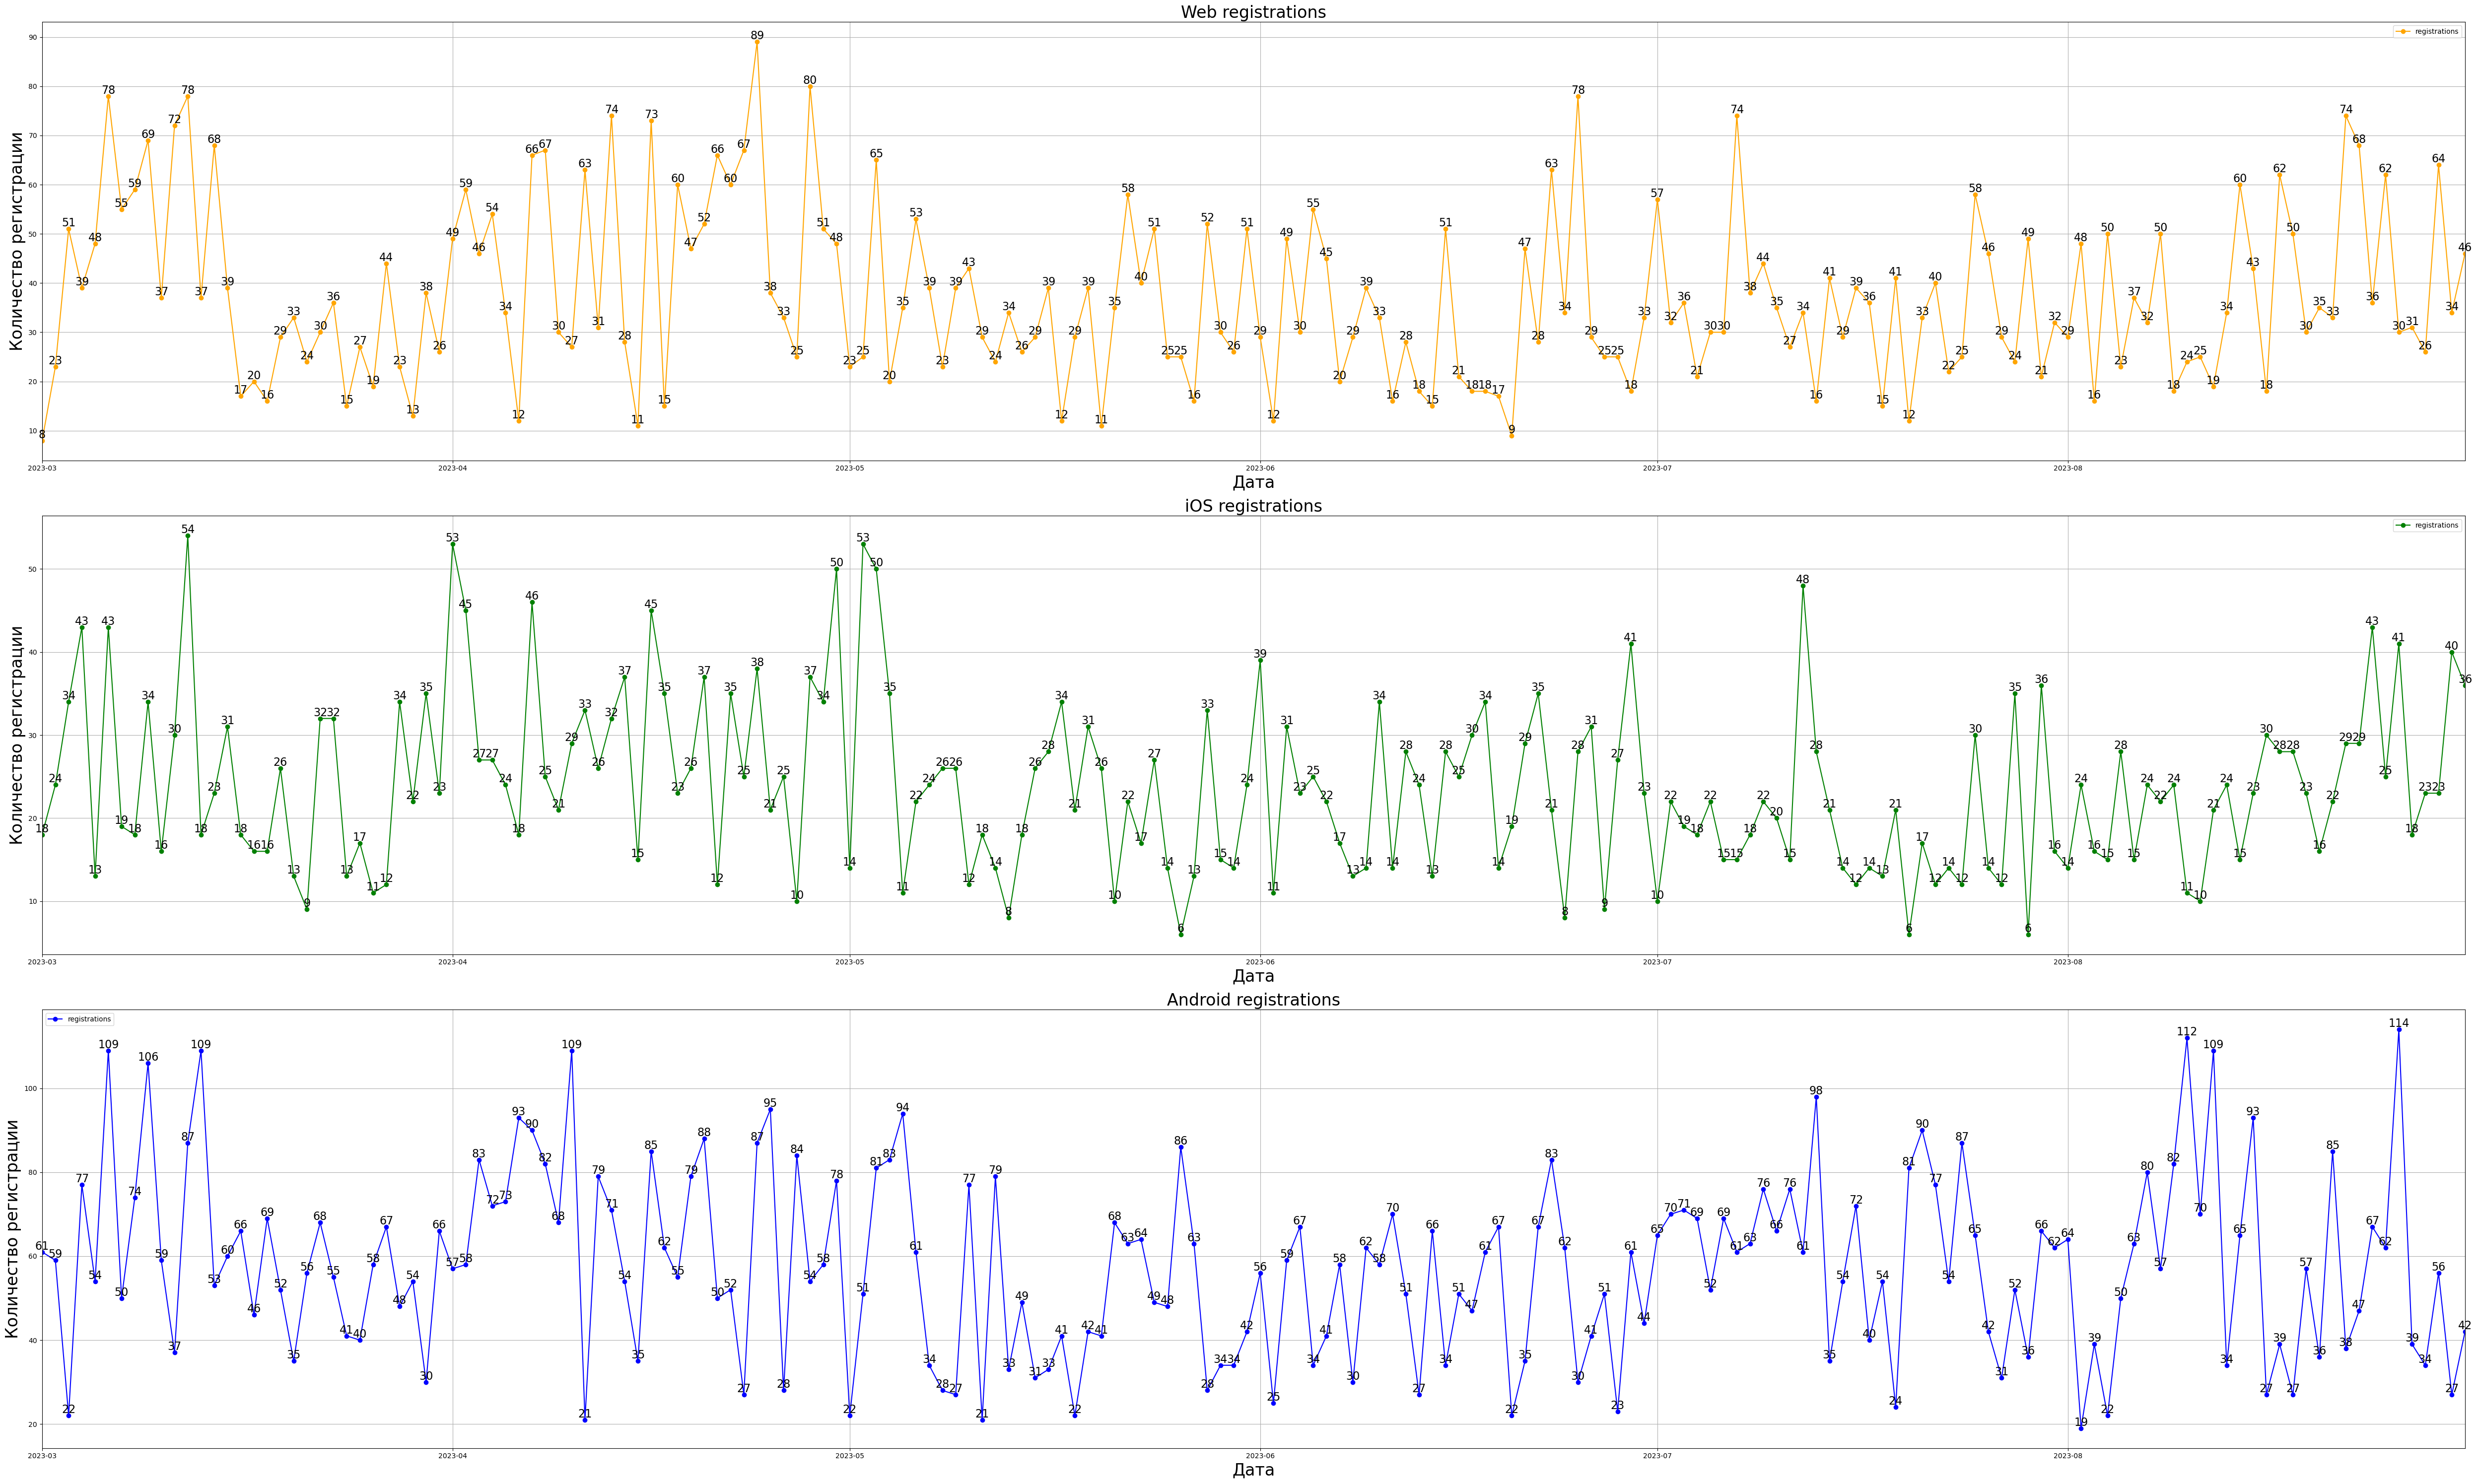

In [41]:
platforms(
    dataframes=[web, ios, android],
    y_col='registrations',
    colors=['orange', 'green', 'blue'],
    titles=['Web registrations', 'iOS registrations', 'Android registrations'],
    save_path='./charts/registrations_dynamic_by_platform.png'
)

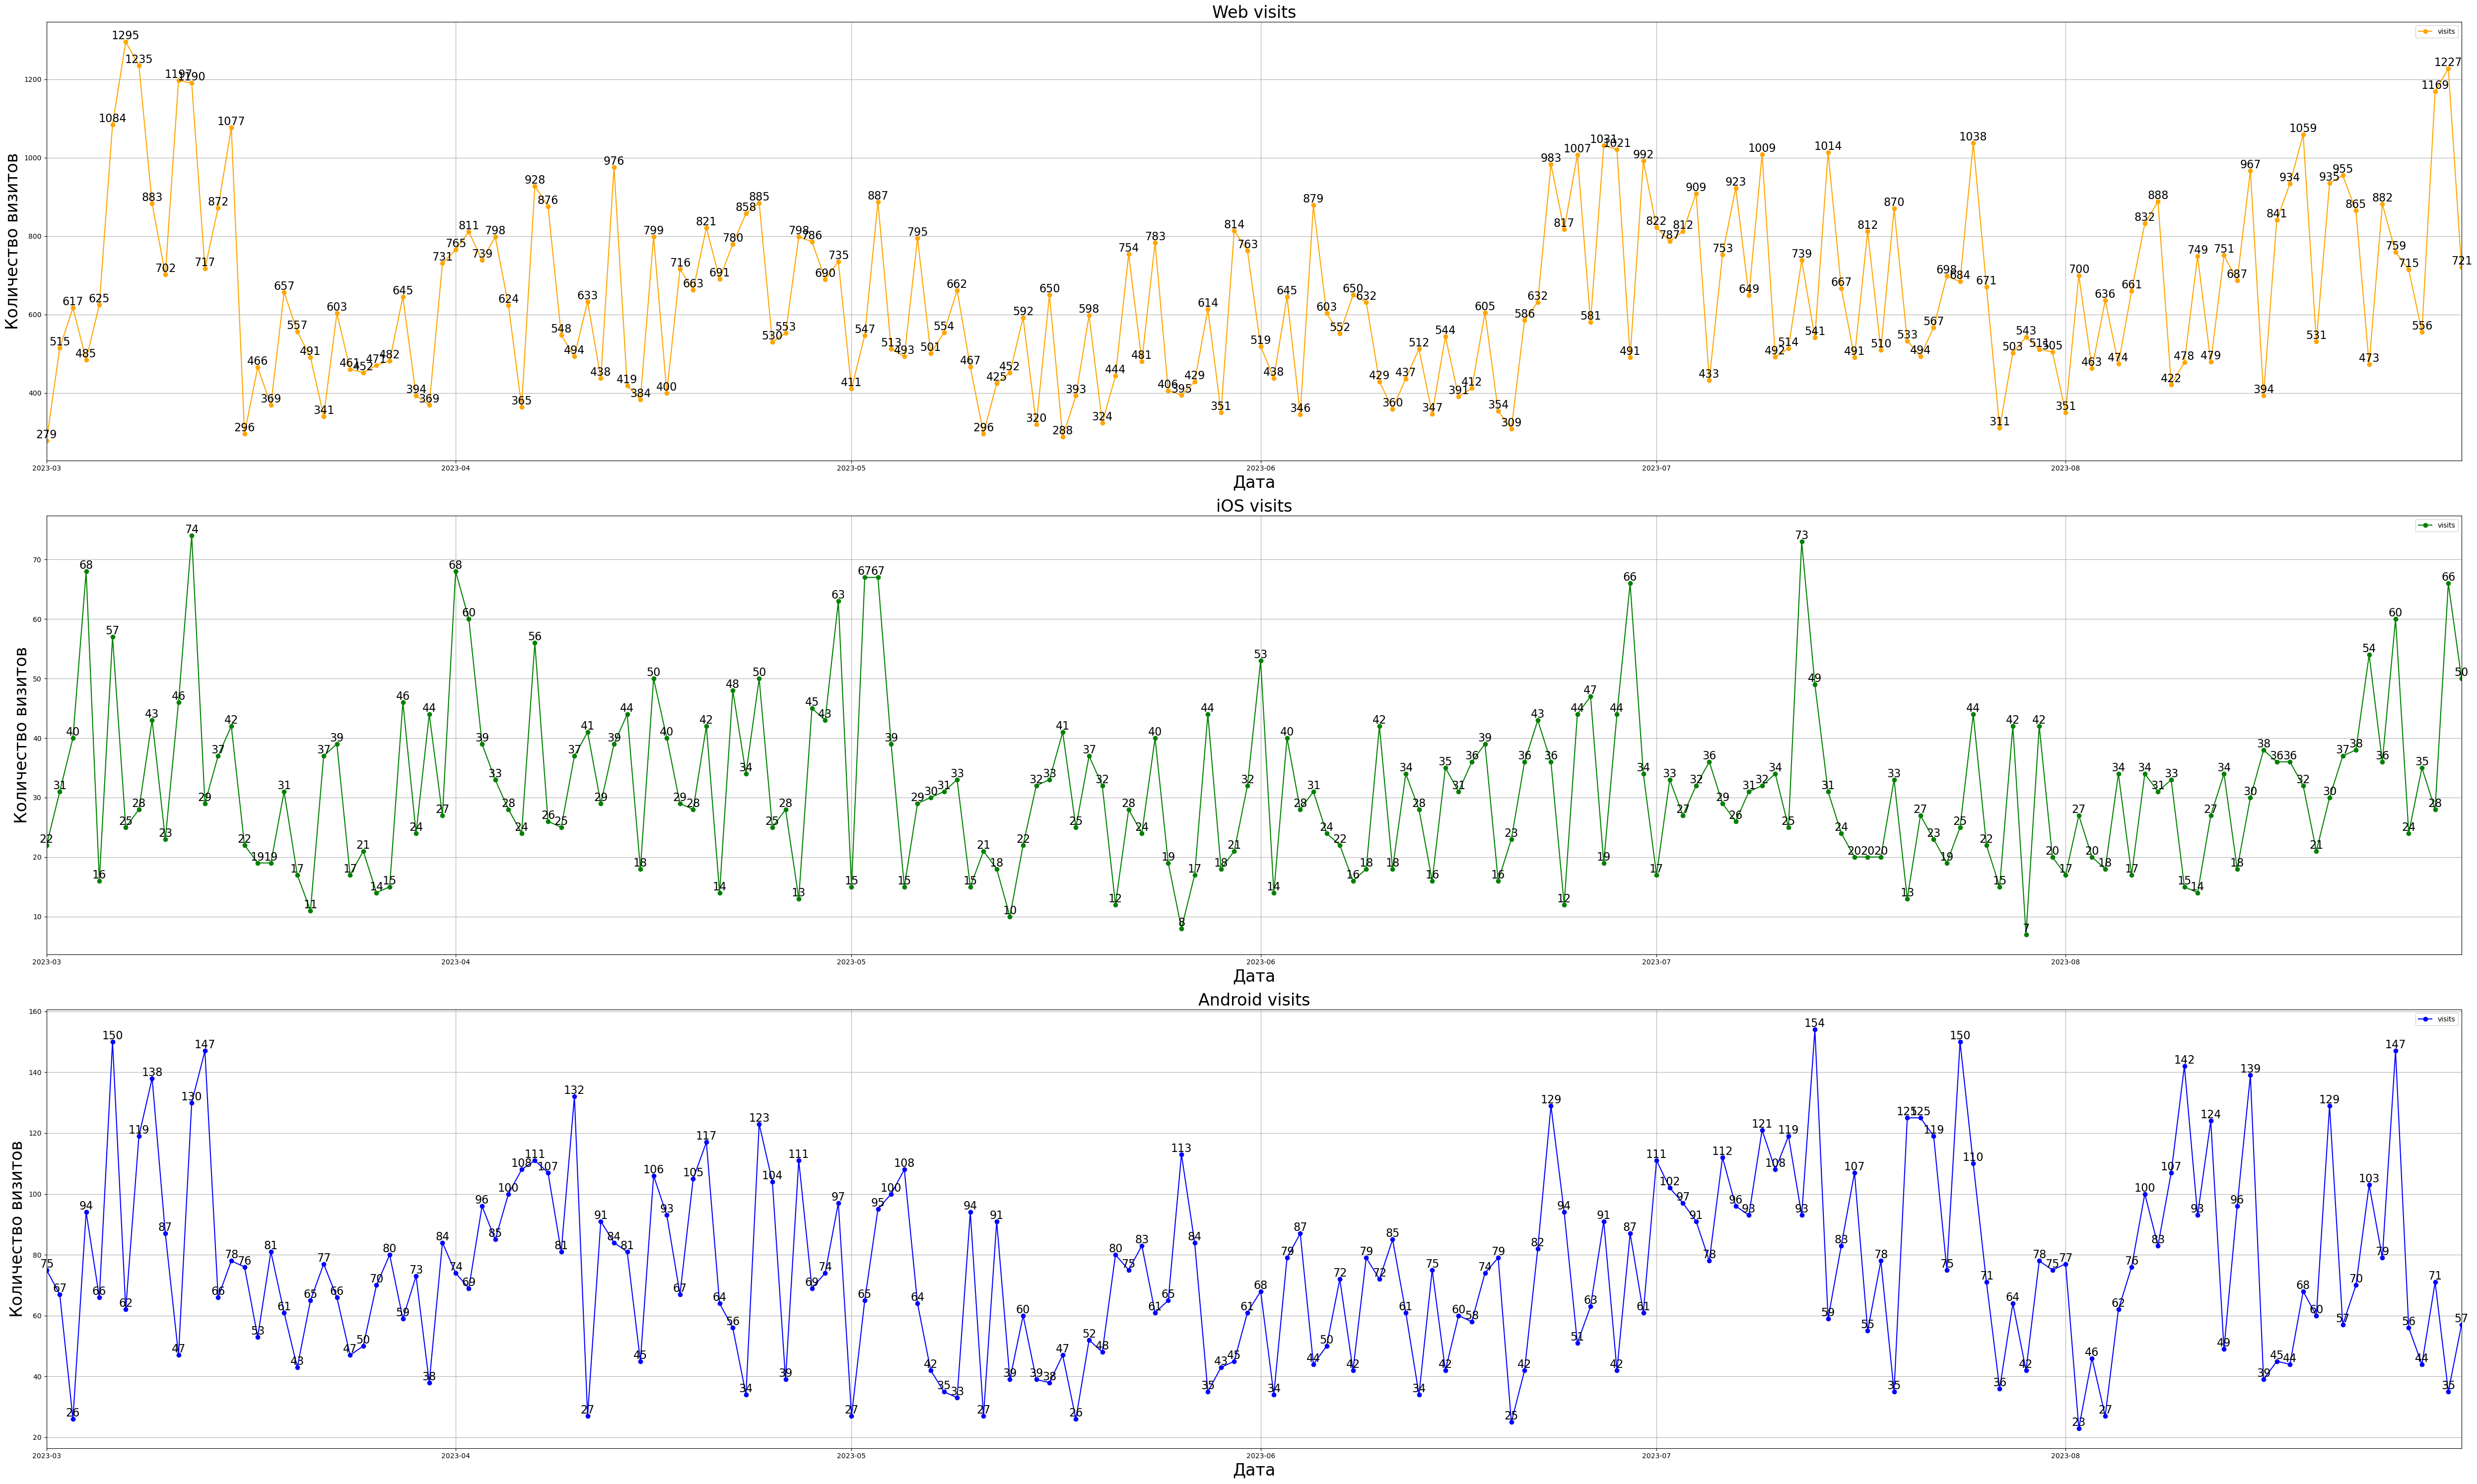

In [42]:
platforms(
    dataframes=[web, ios, android],
    y_col='visits',
    colors=['orange', 'green', 'blue'],
    titles=['Web visits', 'iOS visits', 'Android visits'],
    save_path='./charts/visits_dynamic_by_platform.png'
)

## Функция CONVERSION()

In [44]:
def conversions(data, y_col, colors, titles, save_path): 
    android = data[data['platform'] == 'android'][['date_group', y_col]]
    ios = data[data['platform'] == 'ios'][['date_group', y_col]]
    web = data[data['platform'] == 'web'][['date_group', y_col]]

    platforms_data = [web, ios, android]  

    fig, ax = plt.subplots(3, 1, figsize=(50, 30))

    for i in range(3): 
        df = platforms_data[i]

        df.plot(
            kind='line',
            x='date_group',
            y=y_col,
            marker='o',
            grid=True,
            ax=ax[i],
            color=colors[i]
        )

        ax[i].set_xlim(left=df['date_group'].min(), right=df['date_group'].max())
        ax[i].set_title(titles[i], fontsize=24)
        ax[i].set_xlabel('Дата', fontsize=24)
        ax[i].set_ylabel('Конверсия (%)', fontsize=24)

        for x, y in zip(df['date_group'], df[y_col]):
            ax[i].text(x, y, f'{y:.2f}%', fontsize=12, ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(save_path)

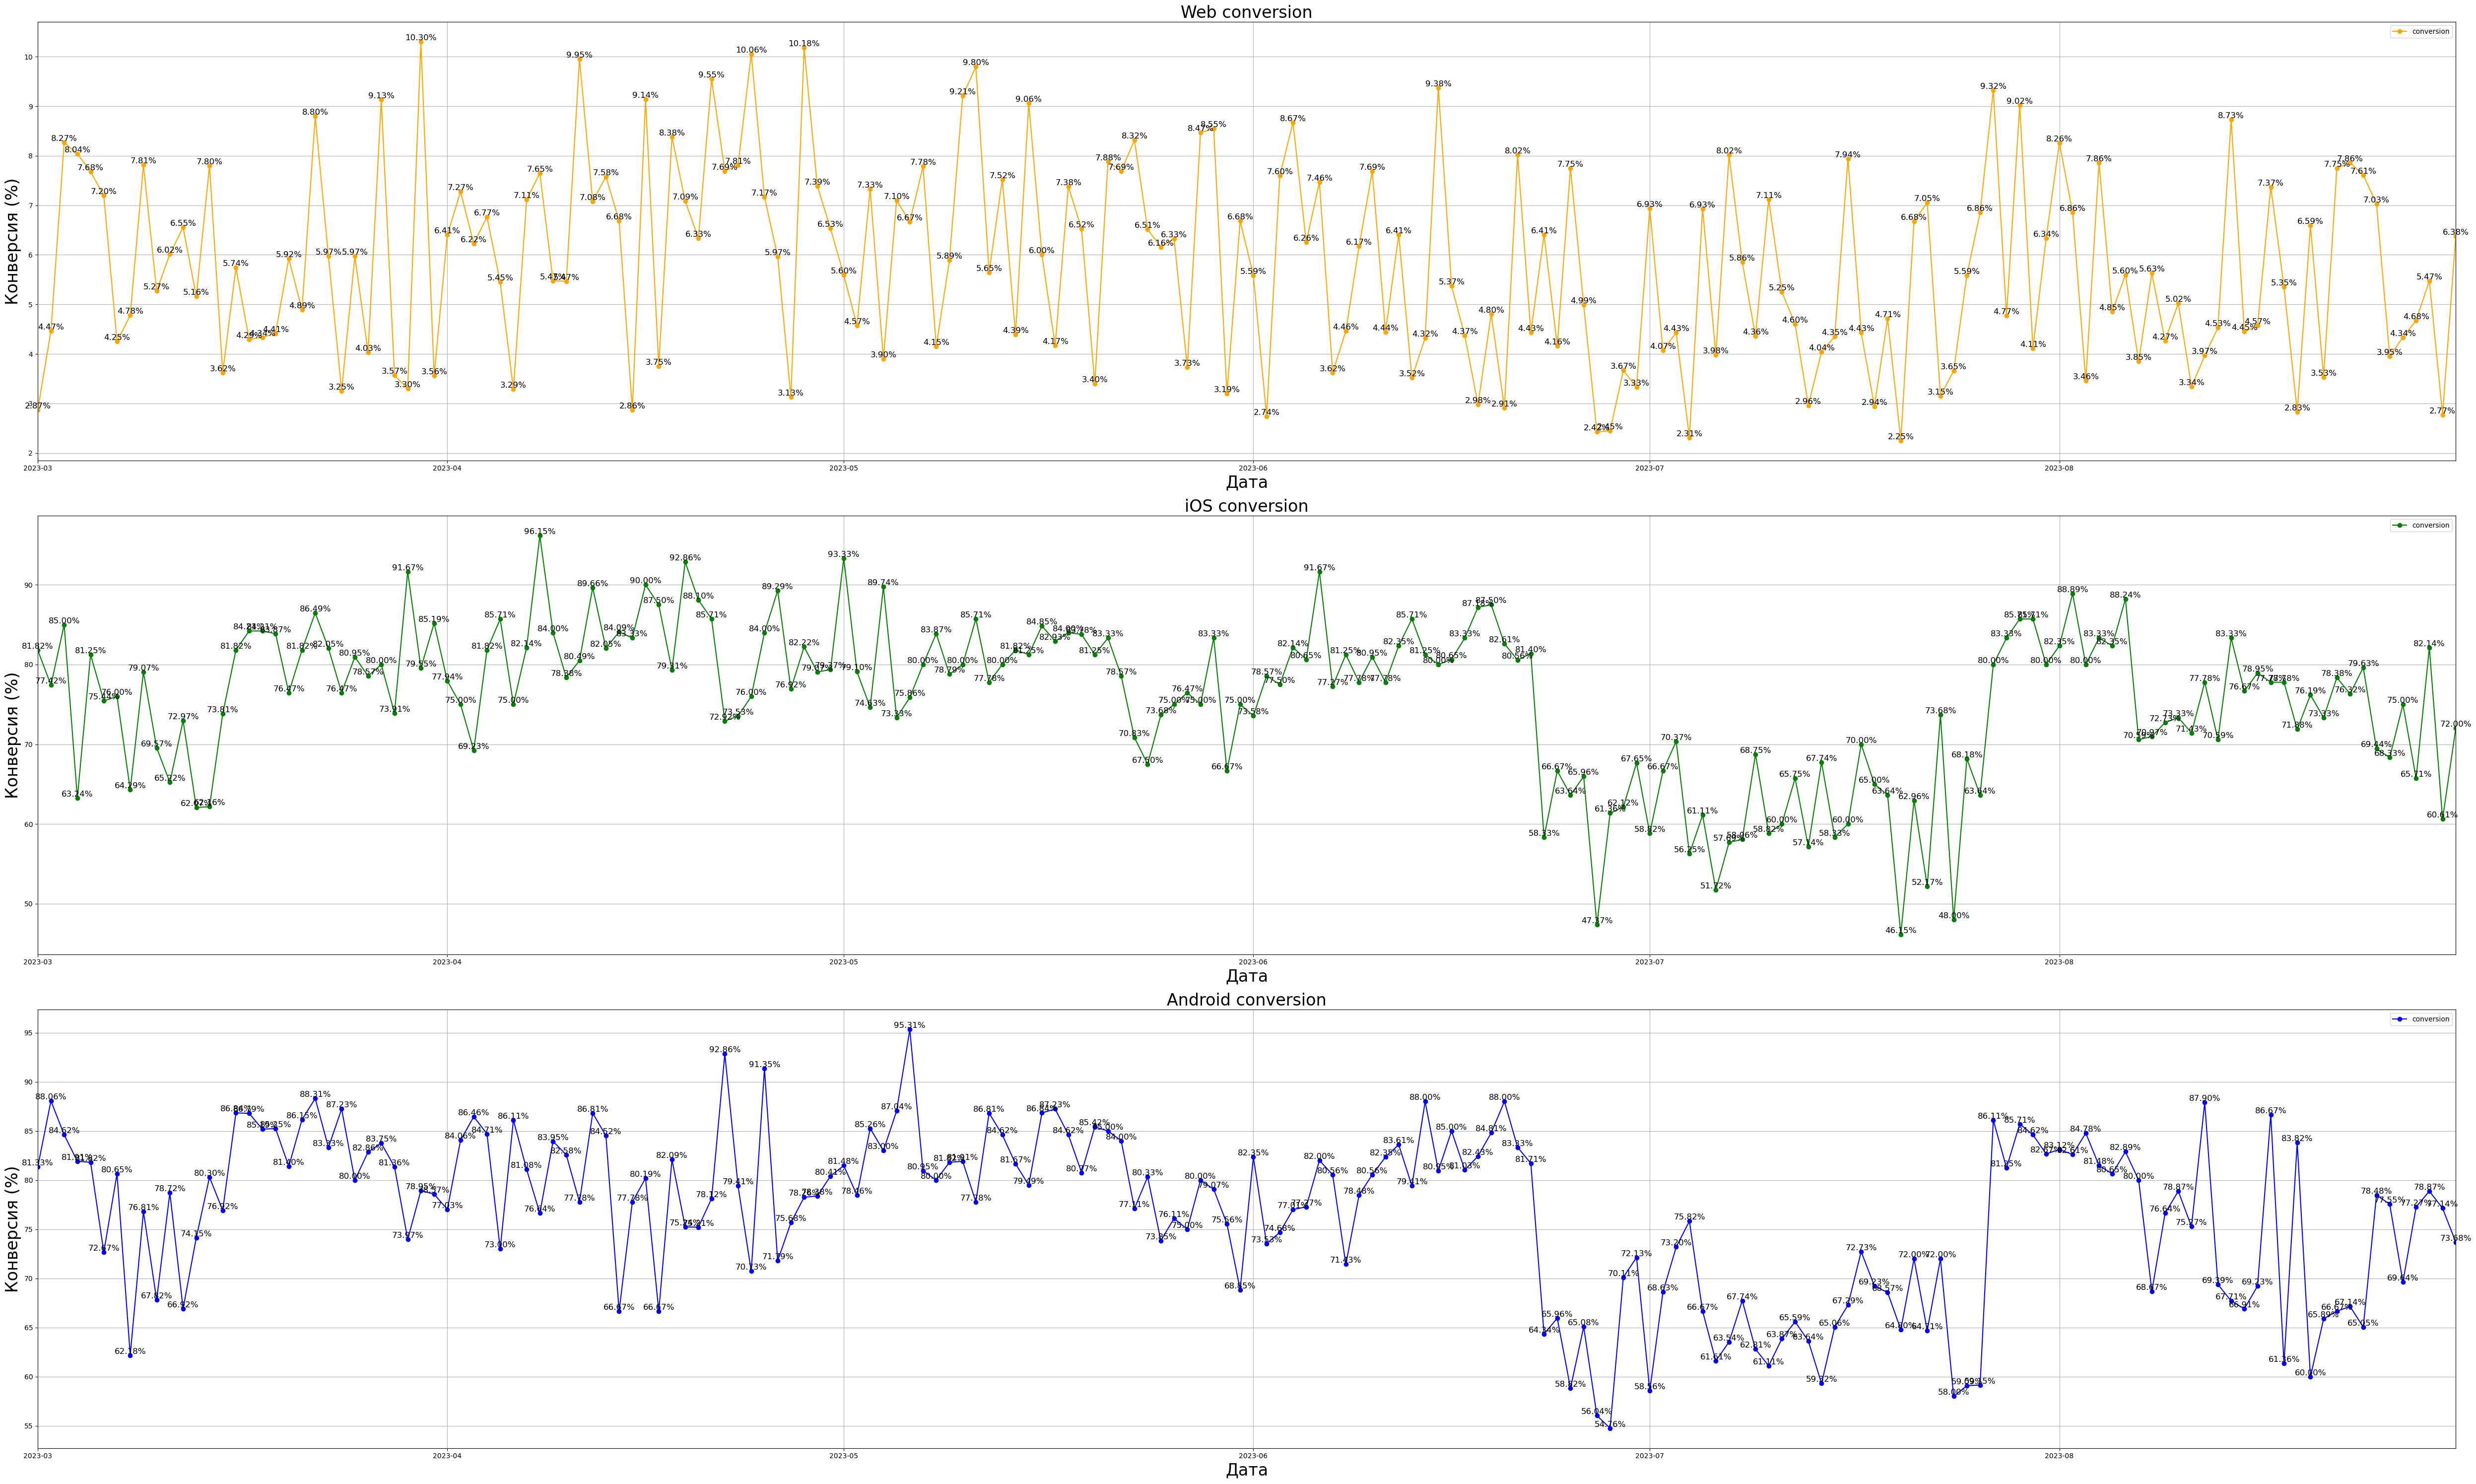

In [45]:
conversions(
    data=data,
    y_col='conversion',
    colors=['orange', 'green', 'blue'],
    titles=['Web conversion', 'iOS conversion', 'Android conversion'],
    save_path='./charts/conversion_by_platform.png')

## Функция PLOT_AD_COST()

In [47]:
def plot_ad_costs(datasets, colors, titles, save_path):
    fig, ax = plt.subplots(len(datasets), 1, figsize=(50, 20 * len(datasets)))

    for i, df in enumerate(datasets):
        df[['date_group', 'ads_cost']].plot(
            kind='bar',
            x='date_group',
            y='ads_cost',
            grid=True,
            ax=ax[i],
            color=colors[i]
        )

        ax[i].tick_params(axis='x', labelrotation=45, labelsize=16)
        ax[i].set_xlabel('Дата', fontsize=24)
        ax[i].set_ylabel('Затраты', fontsize=24)
        ax[i].set_title(titles[i], fontsize=24)

    plt.tight_layout()
    plt.savefig(save_path)

In [48]:
advanced_algorithms_series = ads[ads['utm_campaign'] == 'advanced_algorithms_series']
intro_to_python_course = ads[ads['utm_campaign'] == 'intro_to_python_course']
ui_ux_design_drive = ads[ads['utm_campaign'] == 'ui_ux_design_drive']
virtual_reality_workshop = ads[ads['utm_campaign'] == 'virtual_reality_workshop']
women_in_tech_symposium = ads[ads['utm_campaign'] == 'women_in_tech_symposium']

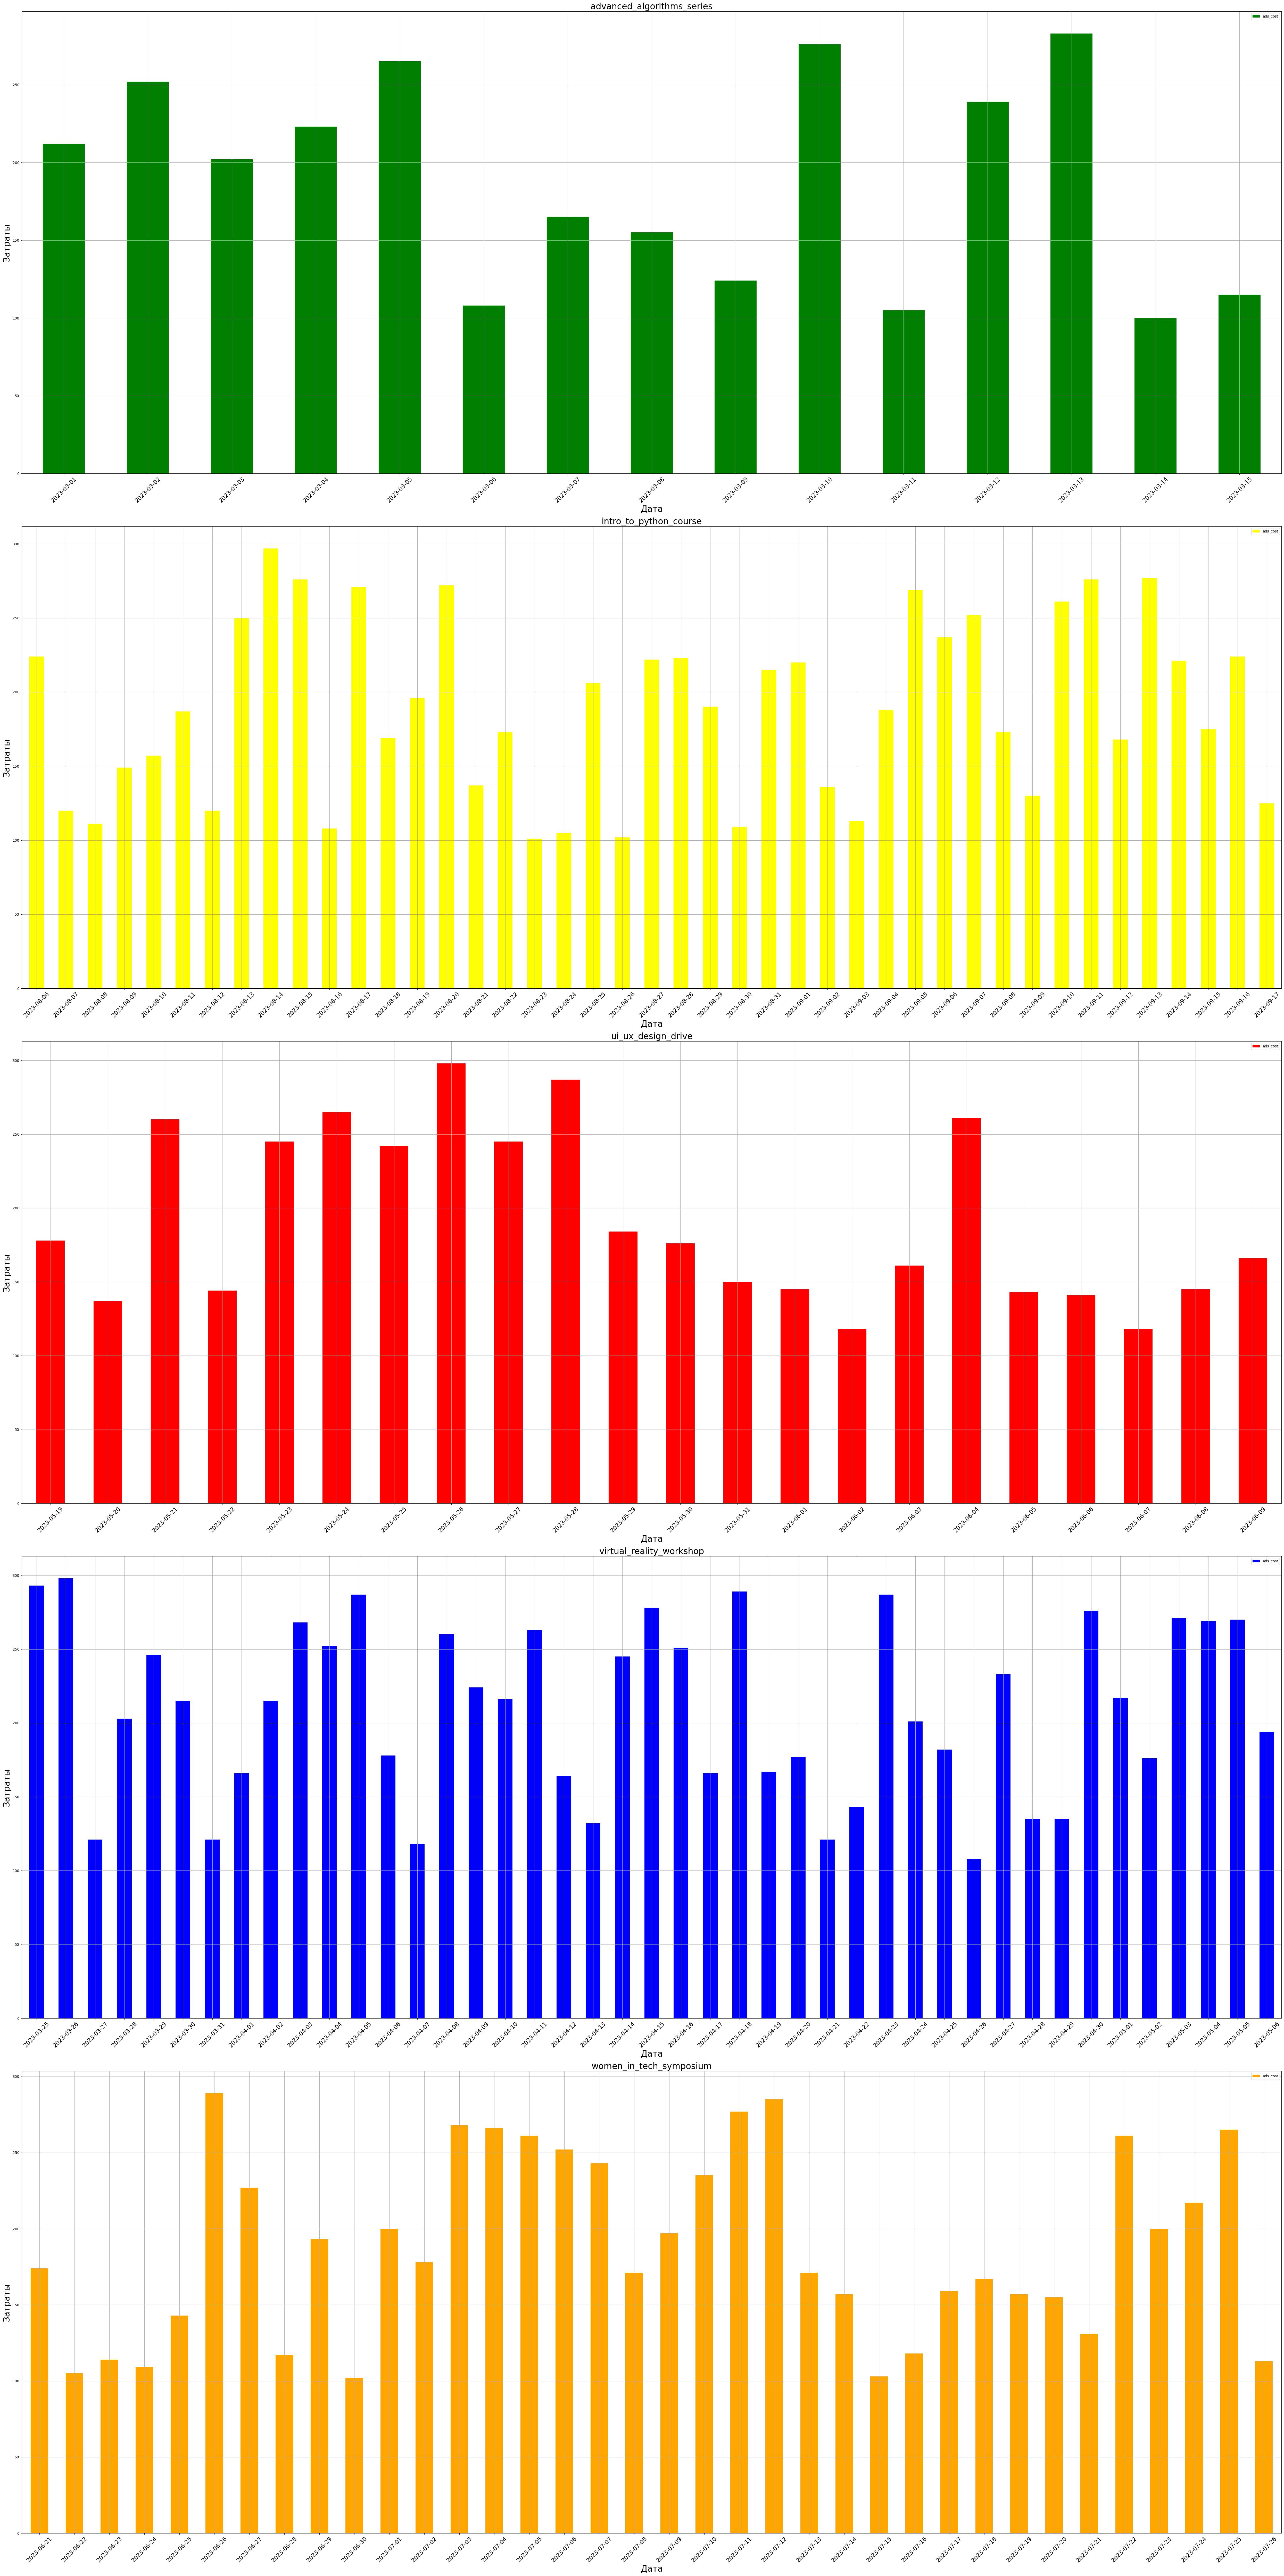

In [49]:
titles = [
        'advanced_algorithms_series',
        'intro_to_python_course',
        'ui_ux_design_drive',
        'virtual_reality_workshop',
        'women_in_tech_symposium'
]

plot_ad_costs(
    datasets=[
        advanced_algorithms_series,
        intro_to_python_course,
        ui_ux_design_drive,
        virtual_reality_workshop,
        women_in_tech_symposium
    ],
    colors=['green', 'yellow', 'red', 'blue', 'orange'],
    titles=titles,
    save_path='./charts/every_ads.png'
)

## Функция ADS_PIE()

In [51]:
ads_source_sum = ads.groupby('utm_source')['ads_cost'].agg('sum')
ads_source_sum

utm_source
google    13813
vk         8135
yandex     9031
Name: ads_cost, dtype: int64

In [52]:
ads_campaign_sum = ads.groupby('utm_campaign')['ads_cost'].agg('sum')
ads_campaign_sum

utm_campaign
advanced_algorithms_series    2824
intro_to_python_course        8135
ui_ux_design_drive            4209
virtual_reality_workshop      9031
women_in_tech_symposium       6780
Name: ads_cost, dtype: int64

In [53]:
def ads_pie(series, title, save_path): 
    plt.figure(figsize=(8, 8))
    series.plot(
        kind='pie',
        autopct='%1.1f%%',
        startangle=90,
        ylabel='',
        title=title
    ) 
    plt.tight_layout()
    plt.savefig(save_path)

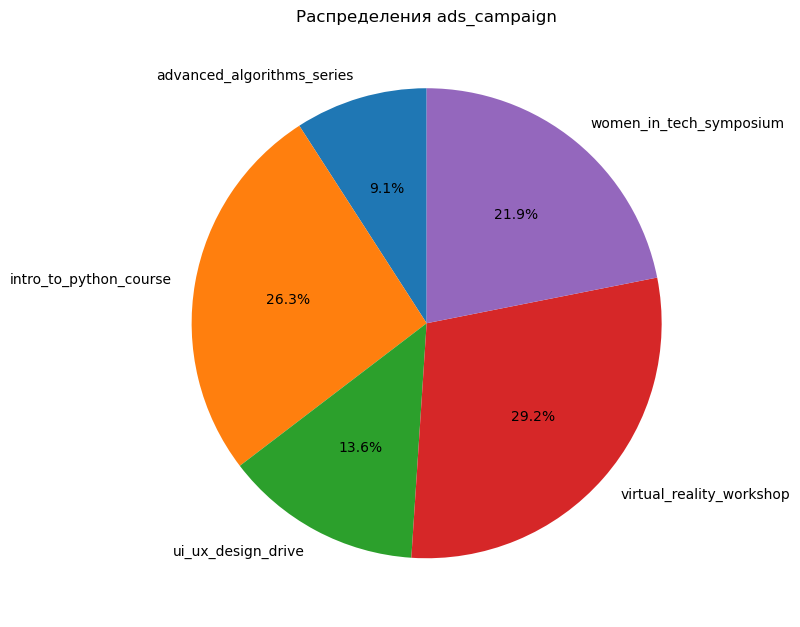

In [54]:
ads_pie(ads_campaign_sum, 'Распределения ads_campaign', './charts/ads_campaign_sum.png')

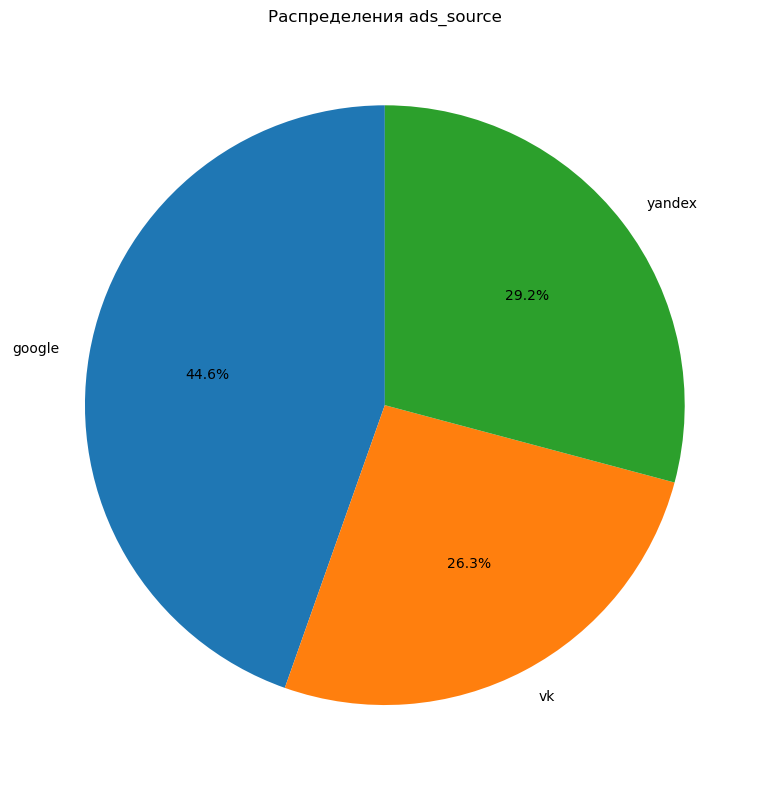

In [55]:
ads_pie(ads_source_sum, 'Распределения ads_source', './charts/ads_source_sum.png')

## Функция ADS_CHECK()

In [57]:
def ads_check(dataframe, ads_df, save_name):
    data = dataframe.copy()
    
    fig, ax = plt.subplots(3, 1, figsize=(20, 15))
    y = ['visits', 'registrations', 'conversion']
    titles = ['Динамика заходов', 'Динамика регистраций', 'Динамика конверсии']
    ylabels = ['Количество заходов', 'Количество регистраций', 'Проценты конверсии']

    for i in range(3):
        data.plot(
            x='date_group',
            y=y[i],
            ax=ax[i],
            color='black',
            marker='o'
        )
        ax[i].set_title(titles[i], fontsize=16)
        ax[i].set_ylabel(ylabels[i], fontsize=14)
        ax[i].set_xlim(left=data['date_group'].min(), right=data['date_group'].max())
        ax[i].grid(True)

    used_labels = set()

    for _, row in ads_df.iterrows():
        label = row['utm_campaign'] if row['utm_campaign'] not in used_labels else None
        for i in range(3):
            ax[i].axvspan(row['min'], row['max'], color=row.get('color', 'orange'), alpha=0.2, label=label)
        used_labels.add(row['utm_campaign'])

    ax[0].legend()
    plt.savefig(save_name)

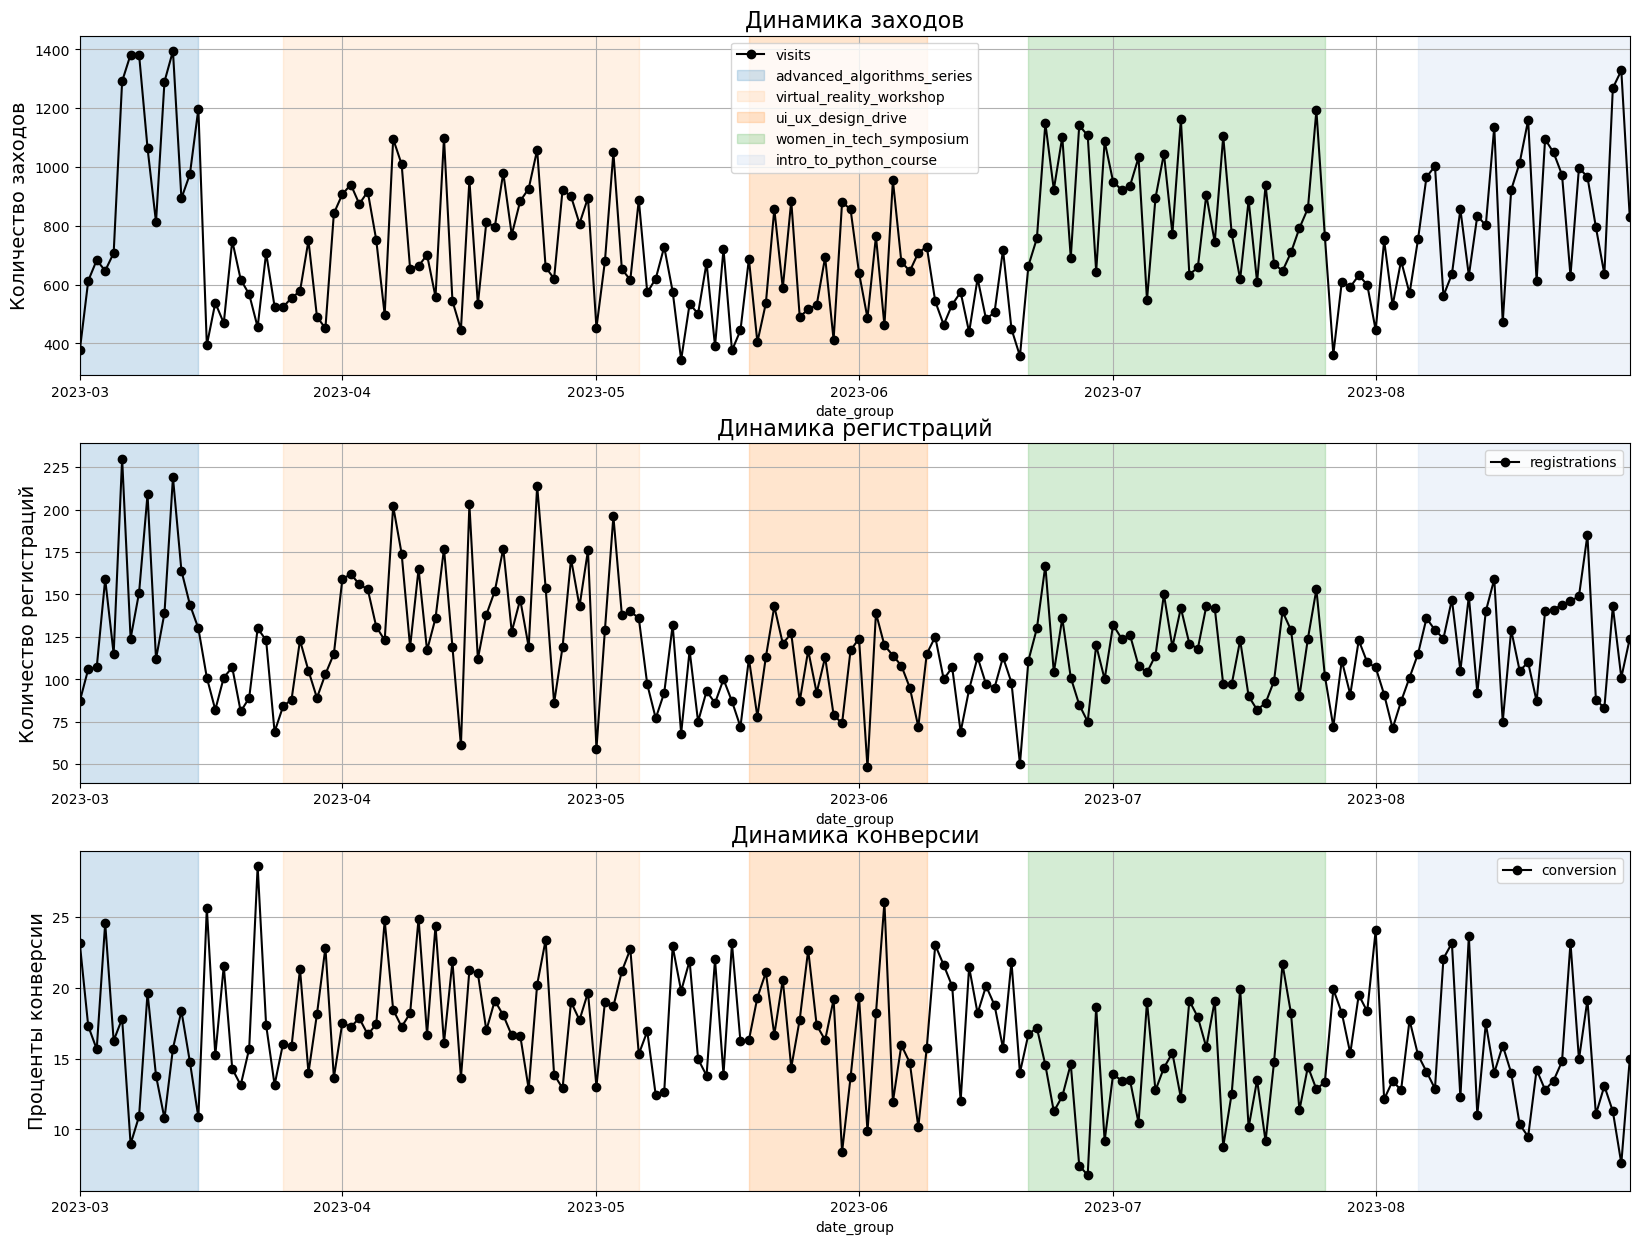

In [58]:
daily_con = conversion.groupby('date_group')[['visits', 'registrations']].agg('sum').reset_index()
daily_con['conversion'] = daily_con['registrations'] * 100.00 / daily_con['visits']
daily_con

ads_df = ads.copy()
ads_df['min'] = ads_df.groupby('utm_campaign')['date_group'].transform('min')
ads_df['max'] = ads_df.groupby('utm_campaign')['date_group'].transform('max')
ads_df['color'] = ads_df['utm_campaign'].astype('category').cat.codes  
ads_df['color'] = ads_df['color'].apply(lambda x: plt.cm.tab20(x % 20)) 
ads_df = ads_df.drop_duplicates(subset=['utm_campaign'])  

ads_check(daily_con, ads_df, './charts/ads_check.png')

## Функция COMBINED_METRICS_VS_ADS()

In [60]:
def combined_metrics_vs_ads(conversion_df, ads_df, save_name):

    conversion_df = conversion_df.copy()
    ads_df = ads_df.copy()

    conversion_df['date_group'] = pd.to_datetime(conversion_df['date_group'])
    ads_df['date_group'] = pd.to_datetime(ads_df['date_group'])

    ads_cost_by_date = ads_df.groupby('date_group', as_index=False)['ads_cost'].sum()

    merged = pd.merge(
        conversion_df[['date_group', 'visits', 'registrations']],
        ads_cost_by_date,
        on='date_group',
        how='left'
    )

    melted = merged.melt(
        id_vars=['date_group', 'ads_cost'],
        value_vars=['visits', 'registrations'],
        var_name='metric',
        value_name='value'
    )

    plt.figure(figsize=(16, 6))
    sns.scatterplot(
        data=melted,
        x='date_group',
        y='value',
        hue='metric',
        size='ads_cost',
        sizes=(20, 400),
        palette='Set1',
        legend='brief'
    )

    plt.title('Визиты и регистрации по датам с учётом рекламного бюджета', fontsize=16)
    plt.xlabel('Дата')
    plt.ylabel('Значение метрик')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(save_name)

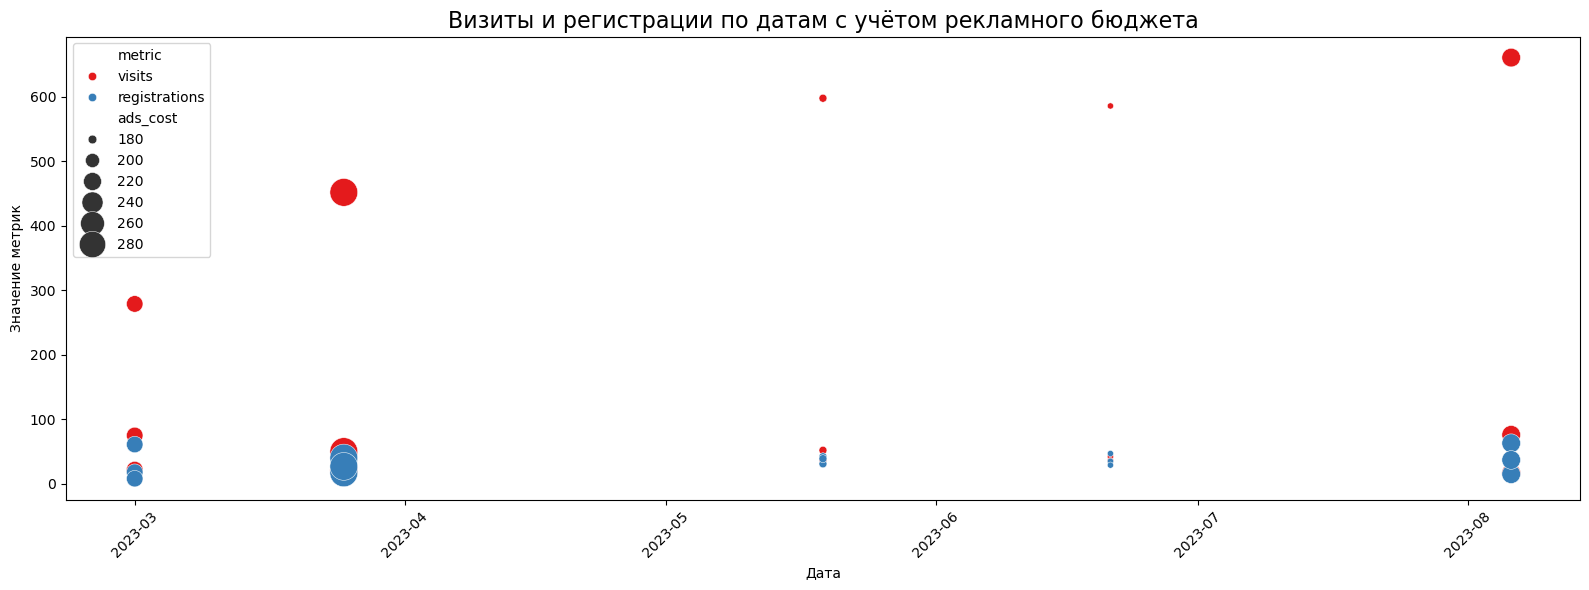

In [61]:
combined_metrics_vs_ads(conversion, ads_df, './charts/combined_metrics_vs_ads.png')

## Функция PLOT_CONVERSION_VS_COST()

In [63]:
def plot_conversion_vs_cost(df, save_name, title='Конверсия vs Бюджет'):
    plt.figure(figsize=(10, 6))
    plt.scatter(df['cost'], df['conversion'], color='dodgerblue', s=100)

    for i in range(len(df)):
        plt.text(df['cost'][i] + 100, df['conversion'][i], df['name'][i], fontsize=9)

    plt.title(title, fontsize=14)
    plt.xlabel('Бюджет, у.е.', fontsize=12)
    plt.ylabel('Конверсия, %', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_name)

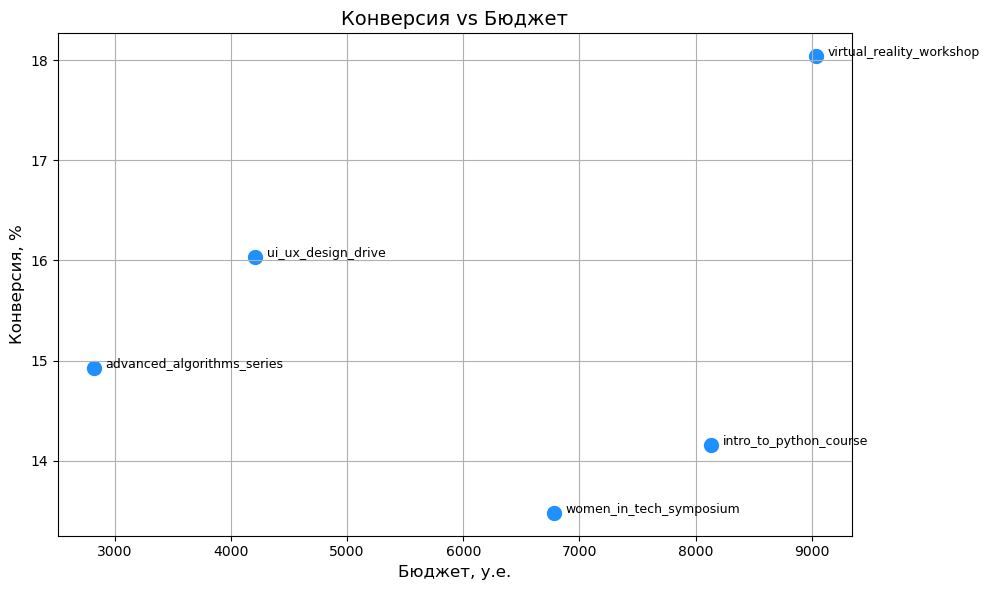

In [64]:
compare = pd.DataFrame([
    {'name': 'advanced_algorithms_series', 'cost': 2824, 'conversion': 14.93},
    {'name': 'intro_to_python_course', 'cost': 8135, 'conversion': 14.16},
    {'name': 'ui_ux_design_drive', 'cost': 4209, 'conversion': 16.03},
    {'name': 'virtual_reality_workshop', 'cost': 9031, 'conversion': 18.04},
    {'name': 'women_in_tech_symposium', 'cost': 6780, 'conversion': 13.48}
])

plot_conversion_vs_cost(compare, './charts/compare.png')

## Функция PLOT_ALL_CAMPAIGNS_TOGETHER()

In [66]:
def plot_all_campaigns_together(ad_info_df, save_name):
    plt.figure(figsize=(14, 7))

    colors = ['red', 'blue', 'yellow', 'green', 'purple']

    for i, row in ad_info_df.iterrows():
        color = colors[i % len(colors)]
        x = [0, 1]
        plt.plot(x, [0, row['visits']], label=f"{row['name']} — визиты", color=color, linewidth=2)
        plt.plot(x, [0, row['regs']], label=f"{row['name']} — регистрации", color=color, linestyle='--', linewidth=2)

    plt.title('Визиты и регистрации по рекламным кампаниям', fontsize=16)
    plt.ylabel('Количество')
    plt.xticks([])
    plt.legend(loc='upper right', fontsize=9)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_name)

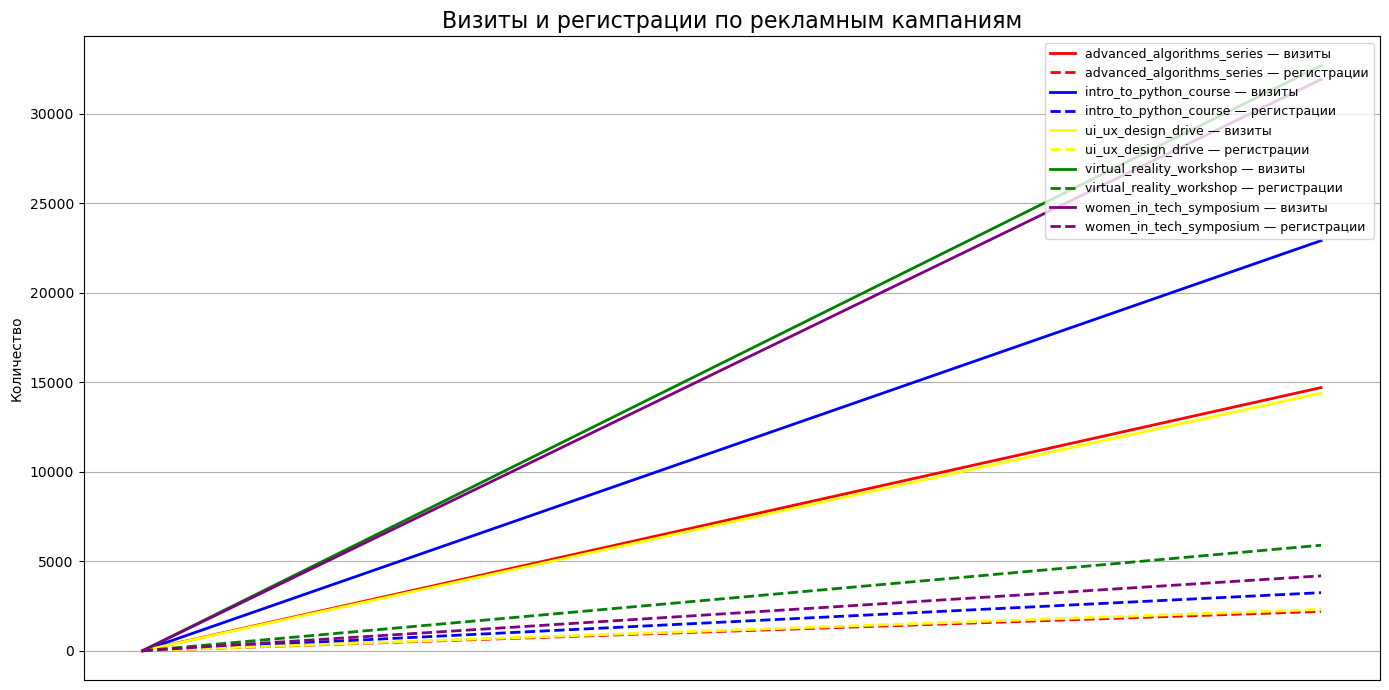

In [67]:
ad_info = pd.DataFrame([
    {'name': 'advanced_algorithms_series', 'visits': 14706, 'regs': 2196},
    {'name': 'intro_to_python_course', 'visits': 22917, 'regs': 3246},
    {'name': 'ui_ux_design_drive', 'visits': 14398, 'regs': 2308},
    {'name': 'virtual_reality_workshop', 'visits': 32698, 'regs': 5898},
    {'name': 'women_in_tech_symposium', 'visits': 31928, 'regs': 4184}
])

plot_all_campaigns_together(ad_info, './charts/ad_info.png')

In [68]:
ads_compare = ads.groupby('utm_campaign')['date_group'].agg(['min', 'max']).reset_index()
ads_compare['diff'] = ads_compare['max'] - ads_compare['min']
ads_compare

,utm_campaign,min,max,diff
0,advanced_algorithms_series,2023-03-01,2023-03-15,"14 days, 0:00:00"
1,intro_to_python_course,2023-08-06,2023-09-17,"42 days, 0:00:00"
2,ui_ux_design_drive,2023-05-19,2023-06-09,"21 days, 0:00:00"
3,virtual_reality_workshop,2023-03-25,2023-05-06,"42 days, 0:00:00"
4,women_in_tech_symposium,2023-06-21,2023-07-26,"35 days, 0:00:00"
